In [1]:
import pandas as pd
import re
from sqlalchemy import create_engine
import os
import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_squared_error
from weather_engine.database import engine
import weather_engine.utils as ut

project_root = ut.get_project_root()

**Constructing DataFrames**

In [2]:
from weather_engine.single_point_features import make_single_point_features

### TEST TEST

datasets, constraints_dict, test_sets = make_single_point_features(
    target_station_id=16,
    upstream_station_ids={"tel_aviv": 178, "haifa": 43},
)

[t+1h] shape=(52581, 97), train=35040, val=8784, test=8757
[t+3h] shape=(52579, 97), train=35040, val=8784, test=8755
[t+6h] shape=(52576, 97), train=35040, val=8784, test=8752
[t+12h] shape=(52570, 97), train=35040, val=8784, test=8746


Filtering feature names that have direct impact on chance of precipitation

**Checking timestamp continuity**

In [3]:
def check_timestamp_holes(df: pd.DataFrame, freq='h'):
    """
    Checks if a DataFrame index has any missing timestamps (holes).
    """
    if df.empty:
        print("DataFrame is empty!")
        return

    if not isinstance(df.index, pd.DatetimeIndex):
        try:
            df.index = pd.to_datetime(df.index)
        except:
            print("Error: Index is not datetime and cannot be converted.")
            return

    start_time = df.index.min()
    end_time = df.index.max()
    perfect_index = pd.date_range(start=start_time, end=end_time, freq=freq)

    missing_timestamps = perfect_index.difference(df.index)

    if len(missing_timestamps) == 0:
        print(f"SUCCESS: No holes found. Timeline is continuous from {start_time} to {end_time}.")
        print(f"Total rows: {len(df)}")
    else:
        print(f"WARNING: Found {len(missing_timestamps)} missing timestamps!")
        print("First 5 missing holes:")
        print(missing_timestamps[:5])

for lag, df in datasets.items():
    print(f"Checking timestamp holes for dataset with {lag} lagged hours")
    check_timestamp_holes(df)

Checking timestamp holes for dataset with 1 lagged hours
SUCCESS: No holes found. Timeline is continuous from 2020-01-02 00:00:00 to 2025-12-31 20:00:00.
Total rows: 52581
Checking timestamp holes for dataset with 3 lagged hours
SUCCESS: No holes found. Timeline is continuous from 2020-01-02 00:00:00 to 2025-12-31 18:00:00.
Total rows: 52579
Checking timestamp holes for dataset with 6 lagged hours
SUCCESS: No holes found. Timeline is continuous from 2020-01-02 00:00:00 to 2025-12-31 15:00:00.
Total rows: 52576
Checking timestamp holes for dataset with 12 lagged hours
SUCCESS: No holes found. Timeline is continuous from 2020-01-02 00:00:00 to 2025-12-31 09:00:00.
Total rows: 52570


**Inspecting rainy months**

/tmp/ipykernel_55234/4163406038.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_rain_counts.index, y=monthly_rain_counts.values, palette="Blues_d")


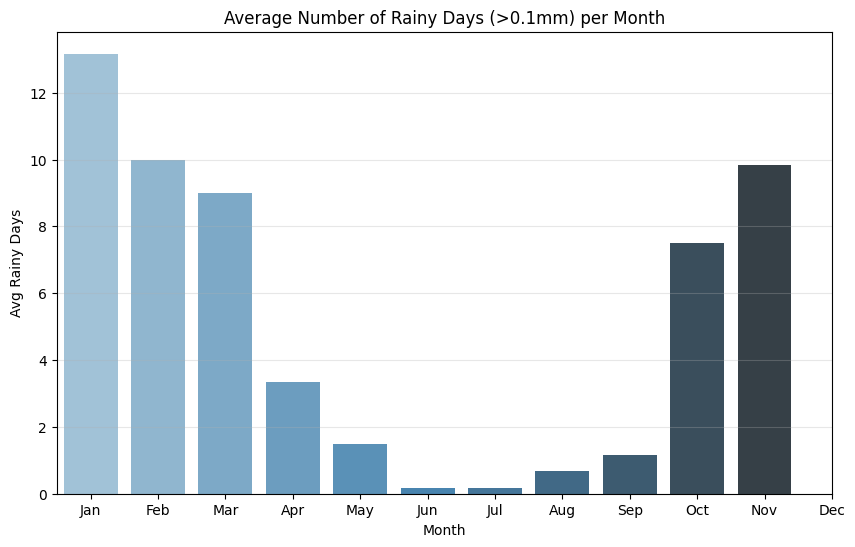

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

target_lags = [1, 3, 6, 12]

# Resample to Daily Totals (since your data is hourly)
# We only care if the WHOLE day had > 0.1mm
curr_df = datasets.get(target_lags[0])
daily_rain = curr_df['rain'].resample('D').sum()

rainy_days = daily_rain[daily_rain > 0.1]

# We normalize by the number of years to get "Average Rainy Days per Month"
unique_years = curr_df.index.year.nunique()
monthly_rain_counts = rainy_days.groupby(rainy_days.index.month).count() / unique_years

plt.figure(figsize=(10, 6))
sns.barplot(x=monthly_rain_counts.index, y=monthly_rain_counts.values, palette="Blues_d")

plt.title(f"Average Number of Rainy Days (>0.1mm) per Month")
plt.xlabel("Month")
plt.ylabel("Avg Rainy Days")
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', alpha=0.3)
plt.show()

**Checking feature correlations**

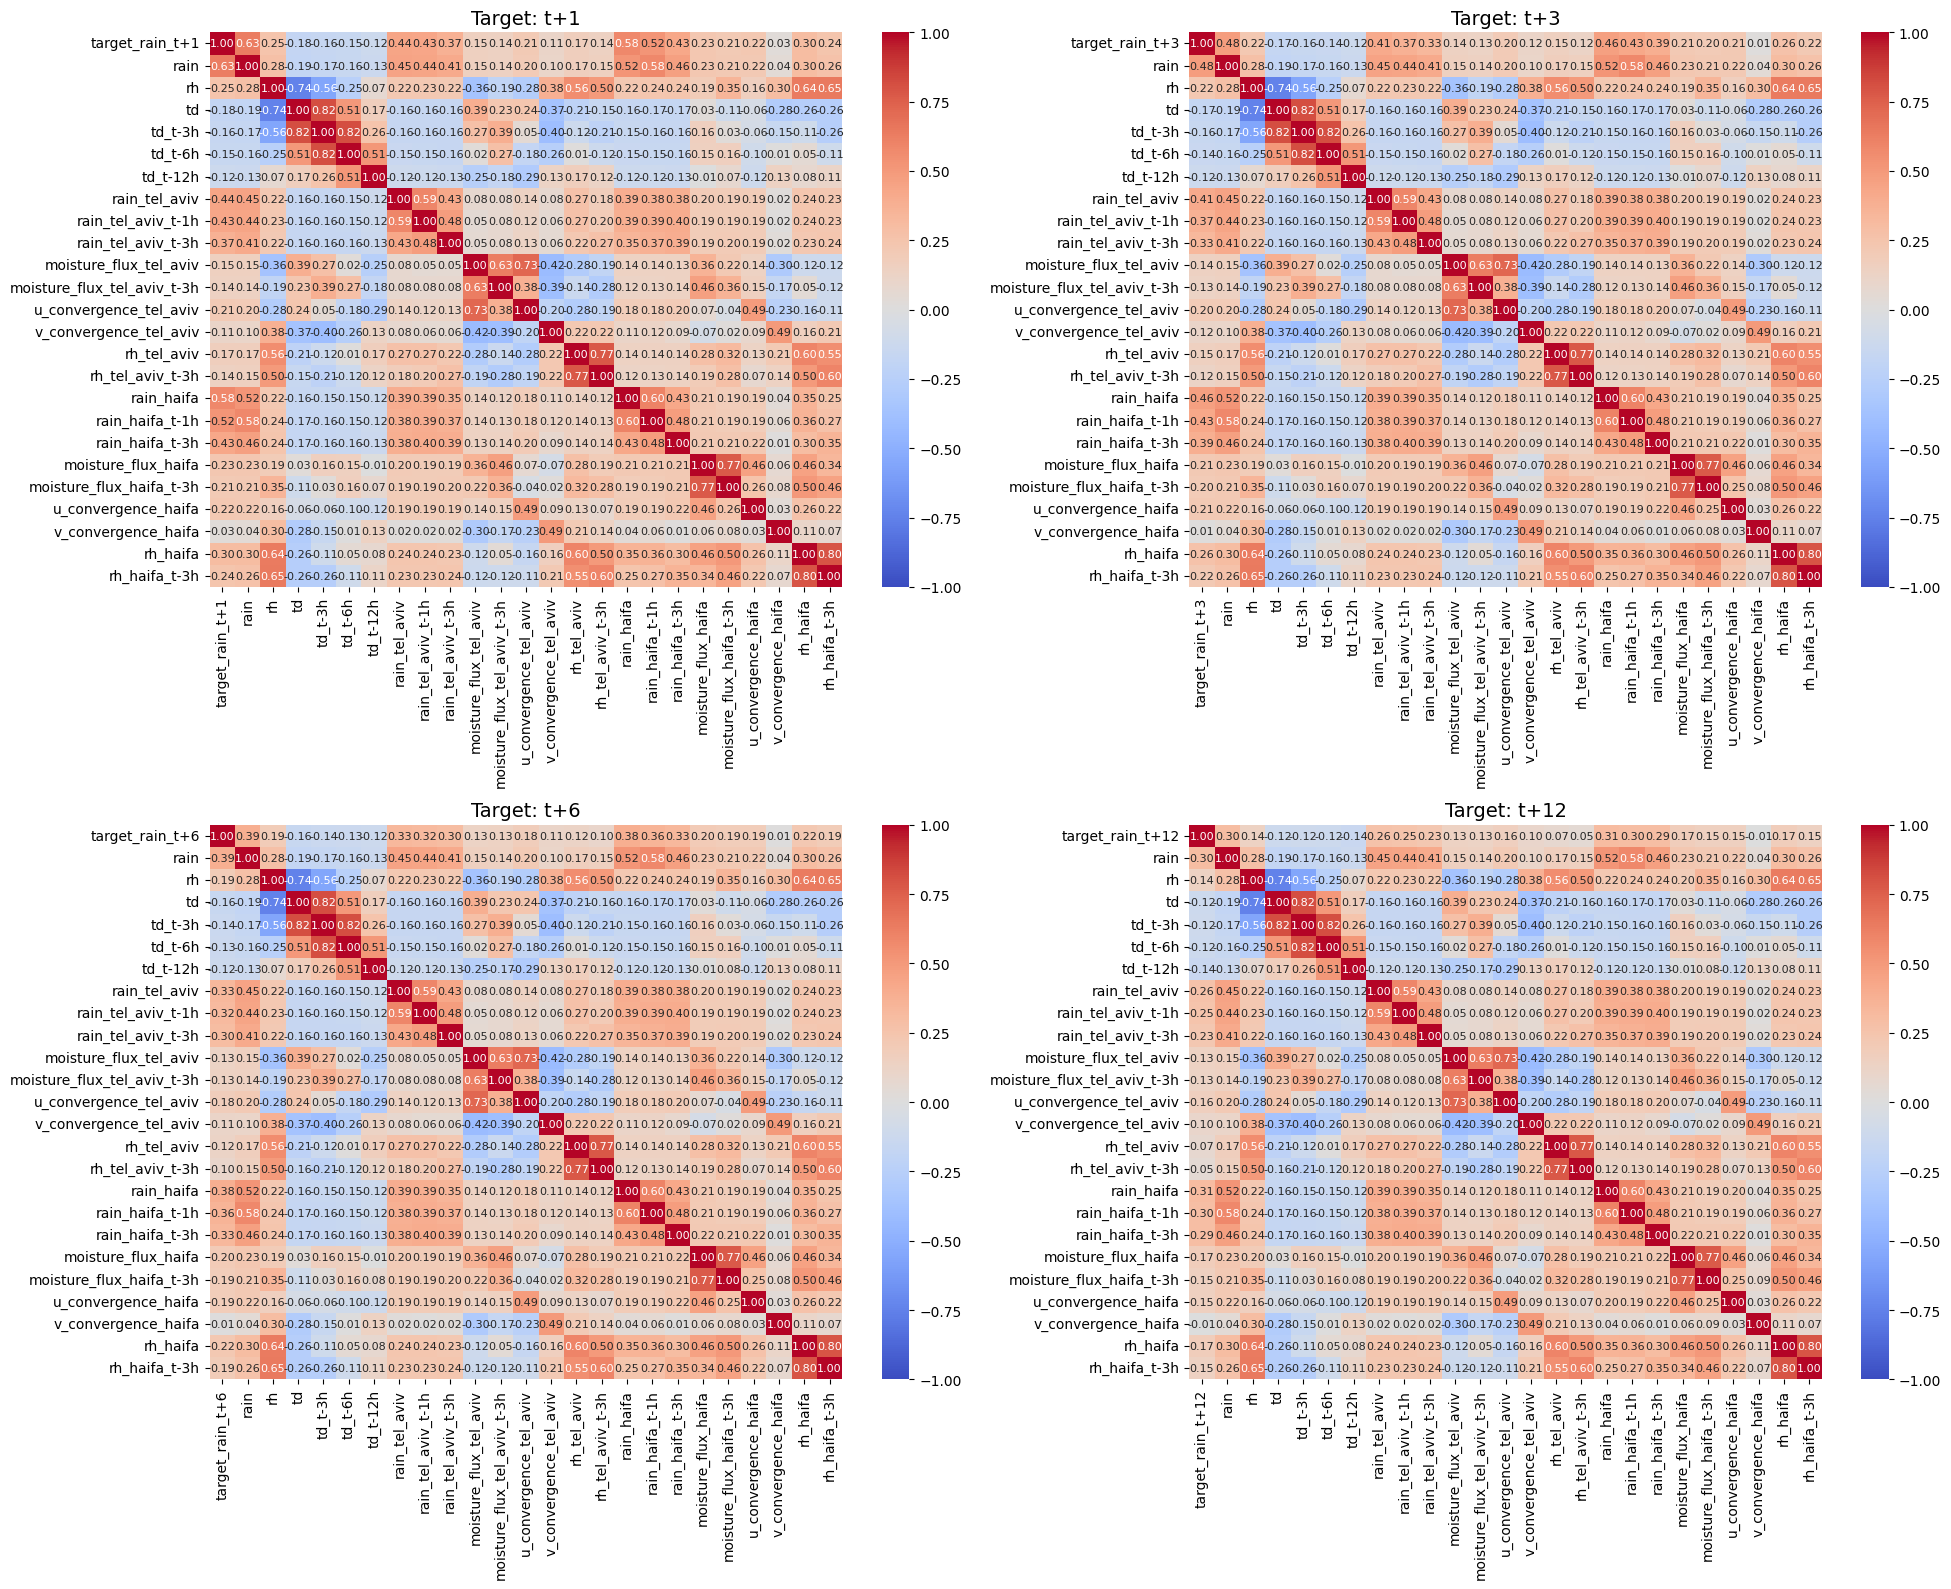

In [5]:
def plot_corr_heatmap(df: pd.DataFrame, target_lag: int, ax) -> None:
    winter_months = [10, 11, 12, 1, 2, 3]
    df_winter = df[df.index.month.isin(winter_months)]

    target_col = f'target_rain_t+{target_lag}'
    corr_cols = [target_col, 'rain', 'rh', 'td', 'td_t-3h', 'td_t-6h', 'td_t-12h',
                 'rain_tel_aviv', 'rain_tel_aviv_t-1h', 'rain_tel_aviv_t-3h',
                 'moisture_flux_tel_aviv', 'moisture_flux_tel_aviv_t-3h',
                 'u_convergence_tel_aviv', 'v_convergence_tel_aviv', 'rh_tel_aviv',
                 'rh_tel_aviv_t-3h', 'rain_haifa', 'rain_haifa_t-1h', 'rain_haifa_t-3h',
                 'moisture_flux_haifa', 'moisture_flux_haifa_t-3h', 'u_convergence_haifa',
                 'v_convergence_haifa', 'rh_haifa', 'rh_haifa_t-3h']

    plot_cols = [c for c in corr_cols if c in df_winter.columns]
    corr_matrix = df_winter[plot_cols].corr(method='spearman')

    # Pass the 'ax' argument to seaborn to constrain it to the grid cell
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, ax=ax, annot_kws={"size": 8})
    ax.set_title(f"Target: t+{target_lag}", fontsize=14)

# Create a 2x2 grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 16))
axes = axes.flatten()

for i, lag in enumerate(target_lags):
    curr_df = datasets.get(lag)
    plot_corr_heatmap(curr_df, lag, axes[i])

plt.tight_layout()
plt.show()


In [6]:
corr_series_dict = {}
winter_months = [10, 11, 12, 1, 2, 3]

# 1. Extract just the feature-to-target correlations for each horizon
for lag in target_lags:
    df_winter = datasets[lag][datasets[lag].index.month.isin(winter_months)]
    target_col = f'target_rain_t+{lag}'
    
    # Calculate spearman and grab JUST the column matching the target
    corr_matrix = df_winter.corr(method='spearman')
    target_corrs = corr_matrix[target_col].drop(target_col) # Drop self-correlation (1.0)
    
    corr_series_dict[f't+{lag}'] = target_corrs

df_shift = pd.DataFrame(corr_series_dict)

# 2. To measure predictive power, we care about the ABSOLUTE correlation 
last_lag = target_lags[-1]
df_shift['Abs_t+1'] = df_shift['t+1'].abs()
df_shift[f'Abs_t+{last_lag}'] = df_shift[f't+{last_lag}'].abs()

# Calculate the shift in absolute predictive power
shift_col_name = f'Power Shift (t+{last_lag} vs t+1)'
df_shift[shift_col_name] = df_shift[f'Abs_t+{last_lag}'] - df_shift['Abs_t+1']

# Drop the temporary absolute columns and sort by the shift
df_shift = df_shift.drop(columns=['Abs_t+1', f'Abs_t+{last_lag}'])
df_shift = df_shift.sort_values(by=shift_col_name, ascending=False)

# 3. Apply a beautiful background gradient (Green = Gained Power, Red = Lost Power)
df_styled = df_shift.style.background_gradient(cmap='RdYlGn', subset=[shift_col_name]) \
                          .background_gradient(cmap='coolwarm', subset=[f't+{lag}' for lag in target_lags]) \
                          .format("{:.3f}")

display(df_styled)


,t+1,t+3,t+6,t+12,Power Shift (t+12 vs t+1)
stdwd,-0.016,-0.047,-0.055,-0.057,0.041
u_vec_t-12h,0.013,0.008,-0.011,-0.036,0.023
td_t-12h,-0.123,-0.117,-0.119,-0.142,0.019
u_vec,0.001,-0.007,-0.001,0.013,0.012
v_vec,0.144,0.162,0.167,0.154,0.011
u_vec_t-6h,0.002,0.004,0.012,-0.011,0.009
u_vec_t-1h,-0.005,-0.006,0.002,0.013,0.009
ws,0.126,0.131,0.127,0.130,0.004
v_vec_tel_aviv,0.191,0.209,0.208,0.194,0.003
u_vec_t-3h,-0.006,-0.001,0.004,0.009,0.003


## Explaining Winter Season Correlation Shifts

1. **The Nowcast Features Losing Correlation:**
    - rain (local): Dropped from 0.628 (t+1) to 0.300 (t+12)
    - rain_haifa: Dropped from 0.578 (t+1) to 0.306 (t+12)

    Current, immediate rainfall is the ultimate predictor for rain 1 hour from now (a storm cell is directly above us). However, storm cells move fast so rain at the current moment gives practically zero physical information about whether a different storm cell will arrive in 12 hours.

2. **The Synoptic Fuel Stays Stable:**
    - moisture_flux_haifa: 0.230 (t+1) down to 0.172 (t+12)
    - td (Dew Point): -0.178 (t+1) down to -0.124 (t+12)

    Moisture flux and regional dew point don't represent tiny fast-moving storm cells, they represent the macro-level weather system (synoptic scale). A giant humid low-pressure system lingering over the Mediterranean dictates the probability of rain for days at a time.


## XGBoost model for each timelagged dataset from t+1 to t+12

In [7]:
models = {}
predictions = {}
ignore_cols = ['timestamp', 'station_id', 'longitude', 'latitude']

for lag in target_lags:
    target_col_name = f'target_rain_t+{lag}'
    print(f"--- Training Model for t+{lag} ---")

    X_train = test_sets[lag]['X_train'].drop(columns=ignore_cols, errors='ignore')
    X_val   = test_sets[lag]['X_val'].drop(columns=ignore_cols, errors='ignore')
    X_test  = test_sets[lag]['X_test'].drop(columns=ignore_cols, errors='ignore')
    y_train = test_sets[lag]['y_train']
    y_val   = test_sets[lag]['y_val']
    y_test  = test_sets[lag]['y_test']

    current_sample_weights = np.ones(len(y_train))
    current_sample_weights[y_train > 0] = 10.0

    current_model = xgb.XGBRegressor(
        n_estimators=5000,
        learning_rate=0.05,
        max_depth=6,
        objective='reg:tweedie',
        tweedie_variance_power=1.5,
        n_jobs=-1,
        early_stopping_rounds=50,
        missing=np.nan,
        monotone_constraints=constraints_dict[lag]
    )

    current_model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        sample_weight=current_sample_weights,
        verbose=False
    )

    predictions[lag] = current_model.predict(X_test)
    models[lag] = current_model
    test_sets[lag]['X_test'] = X_test  # update with ignored cols dropped

    print(f"Model for t+{lag} trained successfully!\n")


--- Training Model for t+1 ---
Model for t+1 trained successfully!

--- Training Model for t+3 ---
Model for t+3 trained successfully!

--- Training Model for t+6 ---
Model for t+6 trained successfully!

--- Training Model for t+12 ---
Model for t+12 trained successfully!



Save the models to json

In [8]:
models_dir = ut.get_project_root() / "models" / "single_point"
models_dir.mkdir(parents=True, exist_ok=True)

for lag, model in models.items():
    model.get_booster().save_model(models_dir / f"xgb_t{lag:+d}.json")

**BASELINE 0 Complexity Model**

In [9]:
preds_presistence = X_test['rain']

Conditional RMSE

In [10]:
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np

def compute_storm_metrics(y_pred, y_test, horizon_label):
    mask_rainy = y_test >= 0.1
    rmse_global = np.sqrt(mean_squared_error(y_test, y_pred))

    if mask_rainy.sum() > 0:
        y_rainy = y_test[mask_rainy]
        pred_rainy = y_pred[mask_rainy]
        
        rmse_rainy = np.sqrt(mean_squared_error(y_rainy, pred_rainy))
        bias = np.mean(pred_rainy - y_rainy)
        scatter_index = (rmse_rainy / np.mean(y_rainy)) * 100
    else:
        rmse_rainy, bias, scatter_index = np.nan, np.nan, np.nan

    return {
        'Horizon': horizon_label,
        'Global RMSE': rmse_global,
        'Storm-Only RMSE': rmse_rainy,
        'Storm Bias': bias,
        'Storm Scatter Index': scatter_index
    }

rmse_results = []

for lag in target_lags:
    y_test_current = test_sets[lag]['y_test']
    preds_current = predictions[lag]
    horizon_str = f"t+{lag}"
    
    metrics = compute_storm_metrics(preds_current, y_test_current, horizon_str)
    rmse_results.append(metrics)

df_rmse = pd.DataFrame(rmse_results).set_index('Horizon')

display(df_rmse.style.format({
    'Global RMSE': '{:.4f} mm',
    'Storm-Only RMSE': '{:.4f} mm',
    'Storm Bias': '{:.2f} mm',
    'Storm Scatter Index': '{:.1f}%'
}).background_gradient(cmap='coolwarm', subset=['Storm-Only RMSE', 'Storm Scatter Index']))


,Global RMSE,Storm-Only RMSE,Storm Bias,Storm Scatter Index
Horizon,,,,
t+1,0.3176 mm,1.7110 mm,-0.44 mm,160.8%
t+3,0.3478 mm,1.7986 mm,-0.52 mm,168.5%
t+6,0.3675 mm,1.8256 mm,-0.56 mm,170.5%
t+12,0.3661 mm,1.8581 mm,-0.67 mm,173.5%


## Plotting feature importances and impacts

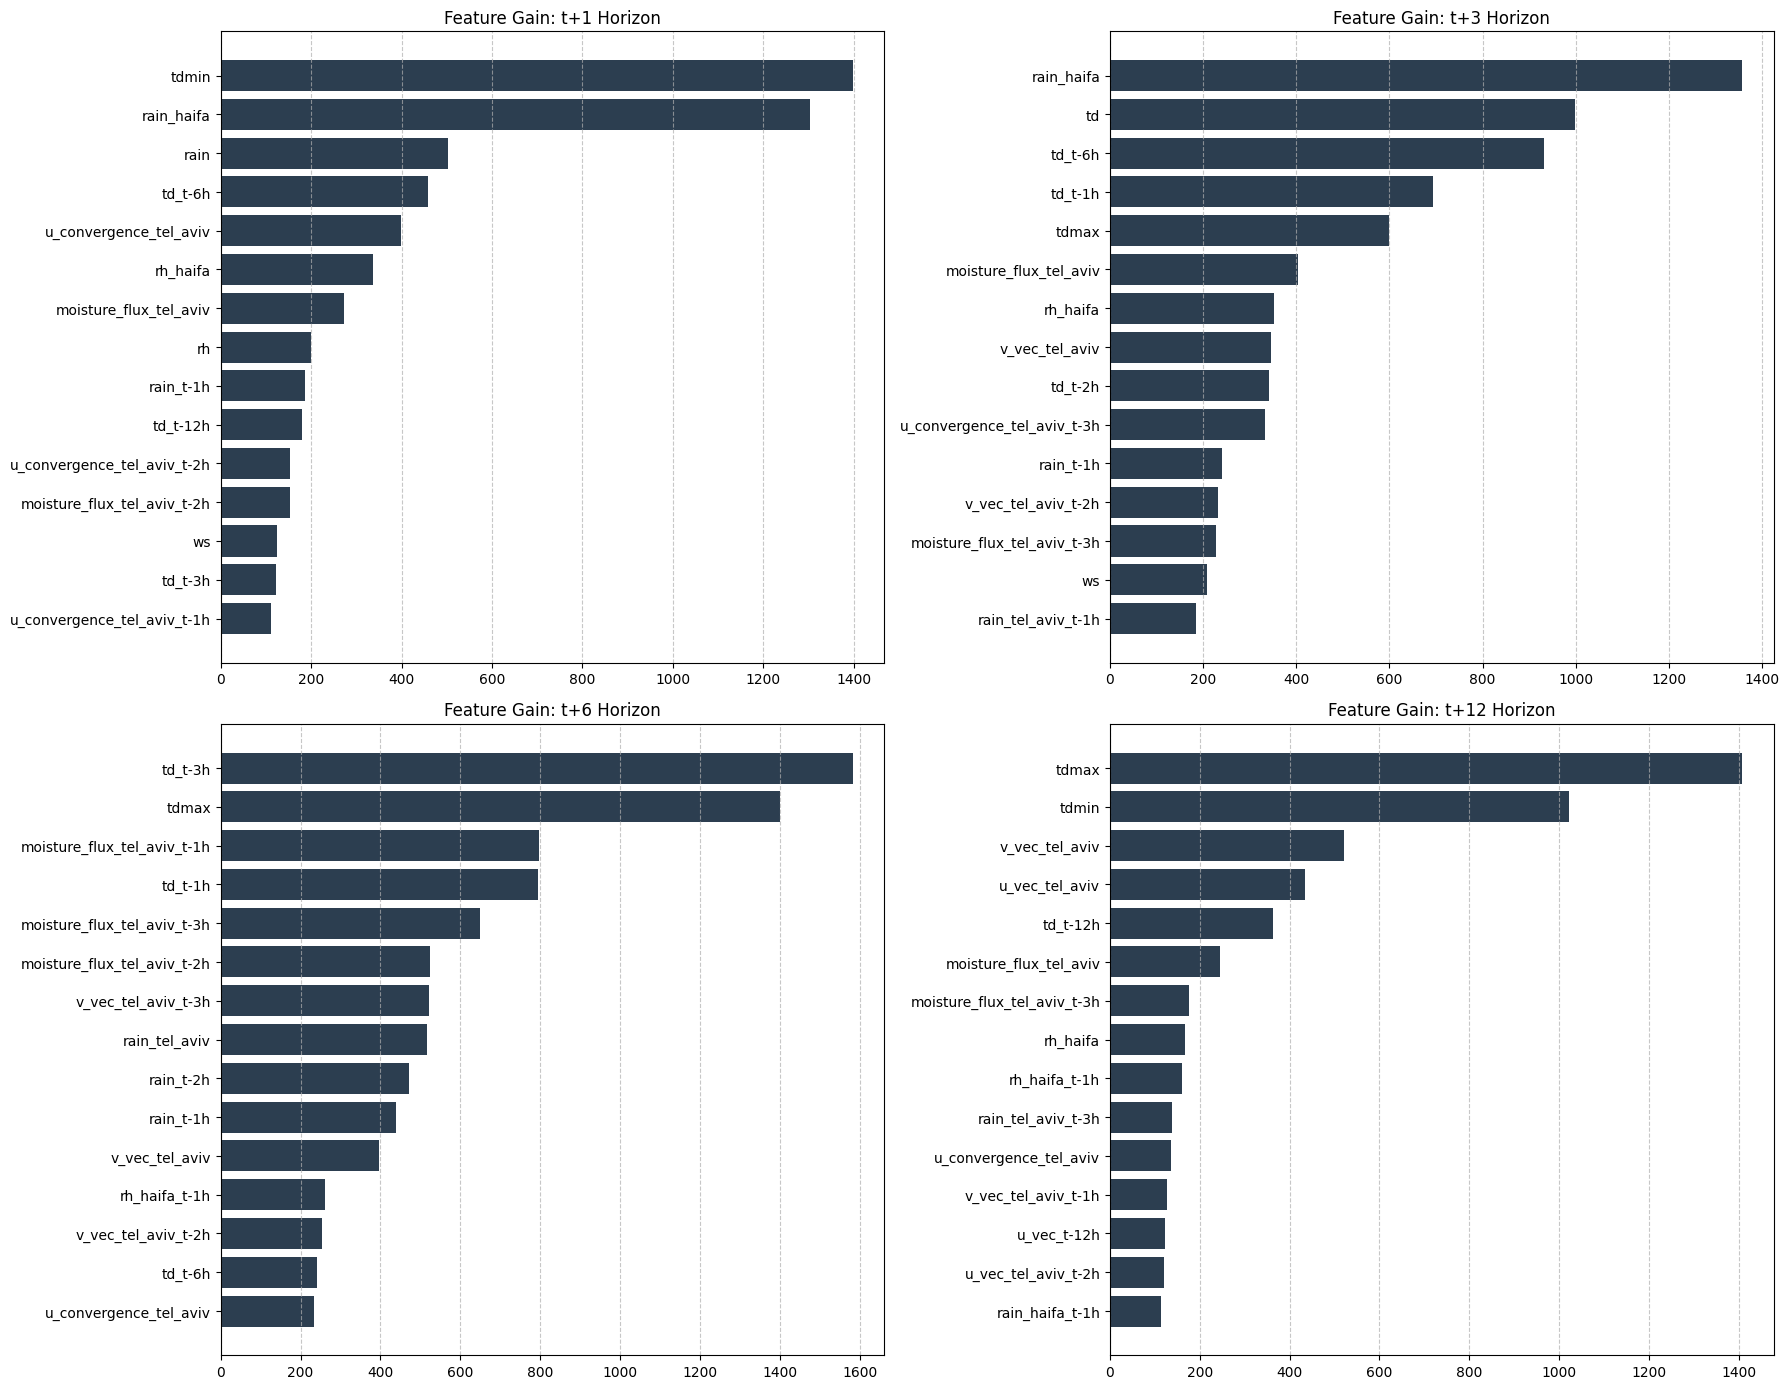

In [11]:
import matplotlib.pyplot as plt

# Create a 2x2 grid for your 4 target lags
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 14))
axes = axes.flatten() # Flatten 2D array of axes for easy looping

for i, lag in enumerate(target_lags):
    model = models[lag]
    ax = axes[i]
    
    importance = model.get_booster().get_score(importance_type='gain')
    sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:15]
    features, scores = zip(*sorted_importance)
    
    ax.barh(features, scores, color='#2c3e50')
    ax.set_title(f'Feature Gain: t+{lag} Horizon')
    ax.invert_yaxis()
    ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


**Feature Importance Shift Analysis**

In [12]:
importance_dict = {}

# 1. Extract raw importance scores for each horizon
for lag in target_lags:
    model = models[lag]
    # get_score returns a dictionary of {feature_name: gain_value}
    raw_scores = model.get_booster().get_score(importance_type='gain')
    importance_dict[f't+{lag}'] = pd.Series(raw_scores)

df_importance = pd.DataFrame(importance_dict)

# If a feature wasn't used in a specific model, its NaN. Fill with 0% importance.
df_importance = df_importance.fillna(0.0)

# 2. Normalize each column to 100% so we can safely compare between models
for lag in target_lags:
    col = f't+{lag}'
    df_importance[col] = (df_importance[col] / df_importance[col].sum()) * 100

# 3. Calculate the Shift in Relative Percentage
last_lag = target_lags[-1]
shift_col_name = f'Importance Shift (t+{last_lag} vs t+1)'
df_importance[shift_col_name] = df_importance[f't+{last_lag}'] - df_importance['t+1']

# Sort to see what gained the most % of importance
df_importance = df_importance.sort_values(by=shift_col_name, ascending=False)

# 4. Apply the background gradient! (Green = Model relies on this MORE over time)
df_importance_styled = df_importance.style.background_gradient(cmap='RdYlGn', subset=[shift_col_name]) \
                                          .background_gradient(cmap='Blues', subset=[f't+{lag}' for lag in target_lags]) \
                                          .format("{:.2f}%")

display(df_importance_styled)


,t+1,t+3,t+6,t+12,Importance Shift (t+12 vs t+1)
tdmax,0.78%,4.77%,9.11%,13.76%,12.98%
v_vec_tel_aviv,0.88%,2.76%,2.58%,5.09%,4.21%
u_vec_tel_aviv,0.31%,0.82%,0.61%,4.25%,3.94%
td_t-12h,2.03%,0.87%,1.47%,3.56%,1.53%
rh_haifa_t-1h,0.25%,0.41%,1.71%,1.56%,1.31%
rain_tel_aviv_t-3h,0.06%,0.76%,0.32%,1.34%,1.28%
moisture_flux_tel_aviv_t-3h,0.58%,1.81%,4.23%,1.71%,1.13%
u_vec_t-12h,0.37%,0.43%,0.52%,1.20%,0.82%
u_vec_tel_aviv_t-2h,0.40%,0.64%,0.80%,1.18%,0.77%
v_convergence_tel_aviv_t-1h,0.22%,0.52%,0.48%,0.96%,0.75%


### **Key Insights from the Power Feature Shift:**

- **The 'Spark' vs The 'Fuel Line':** Notice the shift in the dew point ($td$) features. At $t+1$, immediate temperature drops ($tdmin$) govern 18% of the model's logic, because sudden cooling causes immediate condensation. However, by $t+12$, its importance halves. Instead, the model's attention shifts drastically upward to the continuous "fuel lines"—the maximum dew point capacity ($tdmax$) surges to 12%, and upstream synoptic metrics like wind vectors ($v\_vec$, $u\_vec$) and moisture flux off the coast of Tel Aviv and Haifa gain significant weight!

- **Current Rain is Discarded:** The model organically learned to strip predictive weight from rain and rain_haifa for the $t+12$ forecast. It learned that a rain cell currently over the station will have passed long before the 12-hour horizon arrives.

- **The Diurnal Cycle is Validated:** Features like td_t-12h drastically gain predictive power at the $t+12$ horizon. The model naturally latches onto the 24-hour diurnal heating cycle as a physical baseline for long-range target forecasting.


Binary representation of model's accuracy for precipitation

In [13]:
from sklearn.metrics import precision_recall_fscore_support

summary_metrics = []

for lag in target_lags:
    y_test_current = test_sets[lag]['y_test']
    preds_current = predictions[lag]
    X_test_current = test_sets[lag]['X_test']
    
    y_test_bin = (y_test_current >= 0.1).astype(int)
    preds_bin = (preds_current >= 0.1).astype(int)
    
    # Get Classification Metrics specifically for the "Rain" class (Class 1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test_bin, preds_bin, average='binary', zero_division=0)
    
    mask_miss = (y_test_current >= 0.1) & (preds_current < 0.1)
    df_misses = X_test_current.loc[mask_miss].copy()
    
    if df_misses.empty:
        events_missed = 0
        max_miss = 0.0
        avg_miss = 0.0
    else:
        df_misses['Actual'] = y_test_current.loc[mask_miss]
        events_missed = len(df_misses)
        max_miss = df_misses['Actual'].max()
        avg_miss = df_misses['Actual'].mean()
        
    # Append row
    summary_metrics.append({
        'Horizon': f't+{lag}',
        'Rain Recall (Detection %)': recall,
        'Rain Precision (Accuracy %)': precision,
        'Rain F1-Score': f1,
        'Total Storms Missed': events_missed,
        'Max Rain Missed': max_miss,
        'Avg Rain Missed': avg_miss
    })

df_metrics = pd.DataFrame(summary_metrics).set_index('Horizon')

display(df_metrics.style.format({
    'Rain Recall (Detection %)': '{:.2f}',
    'Rain Precision (Accuracy %)': '{:.2f}',
    'Rain F1-Score': '{:.2f}',
    'Max Rain Missed': '{:.2f} mm/hr',
    'Avg Rain Missed': '{:.2f} mm/hr'
}).background_gradient(cmap='YlOrRd', subset=['Total Storms Missed']))


,Rain Recall (Detection %),Rain Precision (Accuracy %),Rain F1-Score,Total Storms Missed,Max Rain Missed,Avg Rain Missed
Horizon,,,,,,
t+1,0.80,0.45,0.57,57,9.60 mm/hr,0.87 mm/hr
t+3,0.79,0.25,0.38,59,9.60 mm/hr,0.88 mm/hr
t+6,0.82,0.15,0.26,50,7.50 mm/hr,1.05 mm/hr
t+12,0.78,0.13,0.23,61,9.60 mm/hr,1.18 mm/hr


### Model Performance: A Balanced Warning System

By setting the model's alert threshold to exactly match the physical definition of rain (>= 0.1 mm/hr), we achieve a highly practical and safe forecasting system. 

Here are the key takeaways from the metrics:

1. **Consistent Storm Detection (Recall):** The model successfully catches roughly **80% of all storms** across *every single time horizon*. Whether a storm is 1 hour away or 12 hours away, the system's ability to detect it remains steadily reliable.
2. **Favoring Safety:** To make sure it catches 80% of the storms, the alert system is designed to issue false alarms rather than stay quiet. This is exactly what we want in a real-world weather app—it is far safer to carry an umbrella and not need it, than to get caught in a storm unprepared.
3. **Natural Decay (Precision):** Forecasting weather becomes exponentially harder the further into the future we look. At $t+1$, when the model alerts us to rain, it is correct 45% of the time. By $t+12$, that accuracy drops to 12%. It still catches the storms, but it requires throwing a wider net of false alarms to do so.


**Now we save a snapshot of the model's output to use it as ground truth in our tests for testing inference script**

In [14]:
import json

sample_idx = 0
forecast = {}

for lag, model in models.items():
    X_test_current = test_sets[lag]['X_test']
    y_test_current = test_sets[lag]['y_test']
    
    sample_window = X_test_current.iloc[[sample_idx]]
    pred = model.predict(sample_window)[0]
    actual = float(y_test_current.iloc[sample_idx])
    
    forecast[lag] = {
        "predicted": float(pred),
        "actual": actual,
        "error": float(actual - pred)
    }

sample_window = test_sets[1]['X_test'].iloc[[sample_idx]]
print("Timestamp:", test_sets[1]['X_test'].index[sample_idx])
print("\nForecast output:")
for lag, vals in sorted(forecast.items()):
    print(f"  t{lag:+d}h -> predicted: {vals['predicted']:.4f}, actual: {vals['actual']:.4f}, error: {vals['error']:.4f}")

print("\nJSON (for unit test fixture):")
print(json.dumps({
    "input_features": sample_window.iloc[0].to_dict(),
    "forecasts": forecast
}, indent=2))


Timestamp: 2025-01-01 00:00:00

Forecast output:
  t+1h -> predicted: 0.0109, actual: 0.1000, error: 0.0891
  t+3h -> predicted: 0.0547, actual: 0.0000, error: -0.0547
  t+6h -> predicted: 0.0905, actual: 0.0000, error: -0.0905
  t+12h -> predicted: 0.4984, actual: 0.0000, error: -0.4984

JSON (for unit test fixture):
{
  "input_features": {
    "rain": 0.0,
    "ws": 0.5666666666666667,
    "stdwd": 20.45,
    "td": 7.95,
    "rh": 96.0,
    "tdmax": 8.4,
    "tdmin": 7.4,
    "u_vec": 0.22392332505728896,
    "v_vec": -0.3408296166116073,
    "rain_t-1h": 0.0,
    "rain_t-2h": 0.1,
    "rain_t-3h": 0.0,
    "rain_t-6h": 0.0,
    "rain_t-12h": 0.0,
    "rain_t-24h": 0.0,
    "u_vec_t-1h": 0.06398945256471415,
    "u_vec_t-2h": 0.32521891166472144,
    "u_vec_t-3h": 0.5200825568250013,
    "u_vec_t-6h": 0.3857733310340617,
    "u_vec_t-12h": -3.637088815885365,
    "u_vec_t-24h": -3.2219933132997327,
    "v_vec_t-1h": -0.4456629326485486,
    "v_vec_t-2h": -0.5268077459751142,
    "v_v

In [15]:
from weather_engine.utils import get_project_root

output_path = get_project_root() / "tests" / "outputs" / "single_point_truth.json"
output_path.parent.mkdir(parents=True, exist_ok=True)

fixture = {
    "timestamp": str(test_sets[1]['X_test'].index[sample_idx]),
    "input_features": sample_window.iloc[0].to_dict(),
    "forecasts": forecast
}

with open(output_path, "w") as f:
    json.dump(fixture, f, indent=2)

print(f"Saved fixture to {output_path}")


Saved fixture to /home/jadosh/repo/SparseData-AI-Precipitation-Forecasting/tests/outputs/single_point_truth.json
